<a href="https://colab.research.google.com/github/soleildayana/Modern-Astrophysics/blob/main/BlackHoleSilhouette_RaysTracing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/soleildayana/Modern-Astrophysics/blob/main/AstroModerna_Proyecto_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Primer Proyecto Computacional - Astrofísica Moderna
## Astronomía - Universidad de Antioquia
**Soleil Dayana Niño Murcia**

## Problema 1: Sintetización Monte Carlo de la silueta de un agujero negro con Ray Tracing

En este problema simulamos el efecto de lente gravitacional que experimenta la luz que sale de un
disco delgado alrededor de un agujero negro. Lanzamos rayos de luz hacia el agujero negro desde una
"pantalla" de observación distante, distribuidos inicialmente sobre una región circular en el plano $yz$.
Para imitar el desvío de la luz por la curvatura espacio-tiempo, cada rayo se propaga por un medio donde el índice de refracción depende de la distancia al agujero negro.

El disco se modela como un anillo plano centrado en el origen, inclinado con respecto al observador.
Para cada rayo se estudia si el rayo es capturado por el agujero negro o si imacta el disco, para así sintetizar la imagen final.

In [19]:
# Librerías
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.spatial import cKDTree
from scipy.spatial.transform import Rotation

plt.style.use("dark_background")
rng = np.random.default_rng(42)

import warnings
warnings.filterwarnings('ignore')

### Parte 1: Propagación de Rayos de Luz en un ST Curvo mediante Aproximación Eikonal

In [20]:
def uniform_points(n_points, r_outer, r_inner=0.0, rng=rng):
    """Genera n_points distribuidos uniformemente en área dentro de un anillo
    [r_inner, r_outer] (r_inner=0 da un círculo completo). Devuelve (r, theta)."""
    u = rng.uniform(0, 1, n_points)
    r = np.sqrt(r_inner**2 + u * (r_outer**2 - r_inner**2))
    theta = rng.uniform(0, 2 * np.pi, n_points)
    return r, theta

In [21]:
N, R = 500, 70 # Número de puntos y Radio

r0, theta0 = uniform_points(N, r_outer=R)
y0, z0 = r0 * np.sin(theta0), r0 * np.cos(theta0)  # cilíndricas -> cartesianas

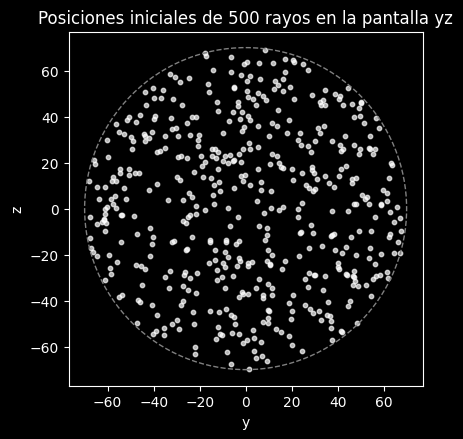

In [22]:
fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.scatter(y0, z0, s=10, c="white", alpha=0.7)
ax.add_patch(plt.Circle((0, 0), R, fill=False, ls="--", color="gray")) # Radio punteado
ax.set_xlabel("y")
ax.set_ylabel("z")
ax.set_aspect("equal")
ax.set_title(f"Posiciones iniciales de {N} rayos en la pantalla yz")
plt.show()

### Parte 2: Integración de Rayos en el Plano xy
Integramos los rayos hacia adelante en el tiempo con las ecuaciones diferenciales de la aproximación eikonal. Para facilitar los cálculos tomamos inicialmente todos los rayos como coplanares (como si estuvieran en el plano $xy$), y más adelante los rotamos a su ángulo de lanzamiento $\theta_0$.

In [23]:
A = 10.0  # radio gravitacional del agujero negro

def refindex(x, y):
    """Índice de refracción efectivo n(x, y) y su gradiente (nx, ny)."""
    eps = 1e-6  # evita singularidades
    r = np.sqrt(x**2 + y**2)
    n = 1 / (1 - A / (r + eps))
    factor = np.abs(1 - 9 * (A / r) ** 2 / 8)
    nx = -factor * n**2 * A * x / (r + eps) ** 3
    ny = -factor * n**2 * A * y / (r + eps) ** 3
    return n, nx, ny


def flow_deriv(state, t):
    """Derivadas [dx/dt, dy/dt, dvx/dt, dvy/dt] para un rayo"""
    x, y, vx, vy = state
    n, nx, ny = refindex(x, y)
    return [vx / n, vy / n, nx, ny]

In [24]:
x_lanzamiento = -100.0     # posición x desde donde se lanzan los rayos
V0 = (1.0, 0.0)       # velocidad inicial (vx, vy)
T_SPAN = np.arange(0, 401, 1)  # integra t in [0, 400] con dt = 1
XY_MAX = 300          # límite de posición para descartar rayos que escapan

def integrate_ray(y_start, t_span=T_SPAN, x_lanzamiento=x_lanzamiento, v0=V0,
                  capture_radius=A, xy_max=XY_MAX):
  """Integra un rayo 2D y trunca su trayectoria en el primer instante en que
  cae al agujero negro o se aleja más allá de xy_max
  en x o en y. Devuelve (trayectoria, capturado)."""
  initial_state = [x_lanzamiento, y_start, *v0]
  trajectory = odeint(flow_deriv, initial_state, t_span)

  x, y = trajectory[:, 0], trajectory[:, 1]
  captured_mask = np.hypot(x, y) <= capture_radius # Filtro de captura
  escaped_mask = (np.abs(x) > xy_max) | (np.abs(y) > xy_max) # Filtro de escape
  stop_indices = np.flatnonzero(captured_mask | escaped_mask)

  if stop_indices.size:
      first_stop = stop_indices[0]
      trajectory = trajectory[: first_stop + 1]
      captured = bool(captured_mask[first_stop])
  else:
      captured = False

  return trajectory, captured

In [25]:
trajectories, captured = zip(*(integrate_ray(y) for y in r0))
captured = np.array(captured)
sum_captured = captured.sum()
print(f"{sum_captured} de {N} rayos fueron capturados por el agujero negro (un {N/sum_captured:0.2}%)")

138 de 500 rayos fueron capturados por el agujero negro (un 3.6%)


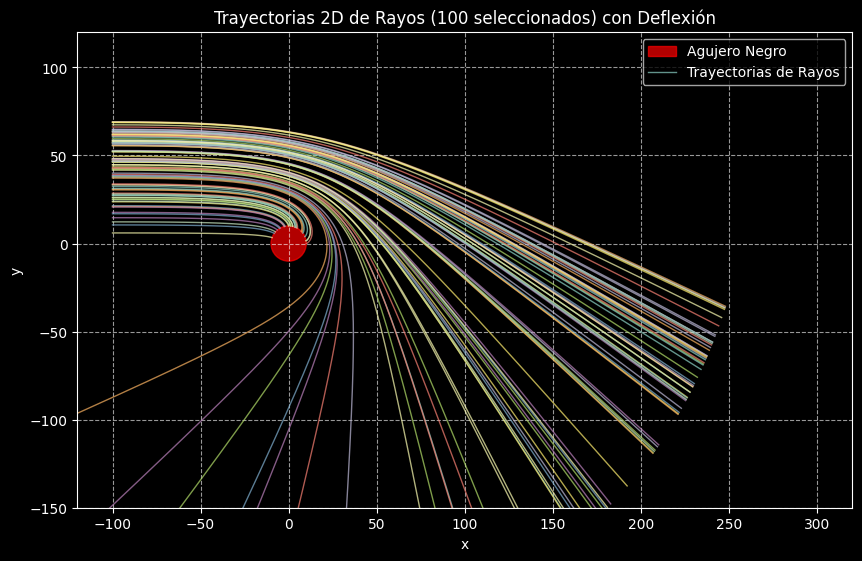

In [26]:
nrays_plot = 100

fig, ax = plt.subplots(figsize=(10, 8))
ax.add_patch(plt.Circle((0, 0), A, color="red", alpha=0.7, label="Agujero Negro"))

for trajectory in trajectories[:nrays_plot]:
    ax.plot(trajectory[:, 0], trajectory[:, 1], linewidth=1, alpha=0.7)

ax.set_title(f"Trayectorias 2D de Rayos ({nrays_plot} seleccionados) con Deflexión")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlim(-120, 320)
ax.set_ylim(-150, 120)
ax.legend(["Agujero Negro", "Trayectorias de Rayos"])
plt.show()

### Parte 3: Construcción de un Disco Inclinado
Generamos un disco de puntos, simulando un disco de acreción delgado alrededor del agujero negro:
$N_d \approx 5000$ posiciones uniformes en área dentro de un anillo con radio interno $R_{in}=15$
y externo $R_{out}=50$, luego inclinado un ángulo $i$ rotándolo alrededor del eje $y$.

In [27]:
Nd, R_int, R_ext = 5000, 15, 50

r_disk, theta_disk = uniform_points(Nd, r_outer=R_ext, r_inner=R_int)
disk_flat = np.column_stack([
    r_disk * np.cos(theta_disk),
    r_disk * np.sin(theta_disk),
    np.zeros(Nd),
])

El espaciamiento promedio entre puntos del disco es dado por
$ d_{ave} = \sqrt{\pi R^2_{out} / N_d}$

Lo calculamos para identificar las intersecciones de rayos con el disco

In [28]:
d_ave = np.sqrt(np.pi * R_ext**2 / Nd)
print(f"d_ave = {d_ave:.4f}")

d_ave = 1.2533


In [29]:
def tilt_disk(disk_points, angle_deg):
    """Inclina el disco angle_deg grados, rotándolo alrededor del eje y."""
    return Rotation.from_euler("y", angle_deg, degrees=True).apply(disk_points)

disk_20deg = tilt_disk(disk_flat, 20)

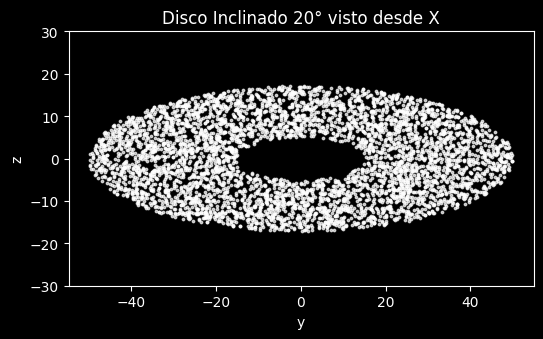

In [30]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(disk_20deg[:, 1], disk_20deg[:, 2], s=3, alpha=0.7, color="white")
ax.set_title("Disco Inclinado 20° visto desde X")
ax.set_xlabel("y")
ax.set_ylabel("z")
ax.set_ylim(-30, 30)
ax.set_aspect("equal")
plt.show()

### Parte 4: Intersecciones Rayo-Disco en 3D y Síntesis de la Imagen
Cada trayectoria vive en el plano $xy$; el rayo real se obtiene rotándola su ángulo de lanzamiento
$\theta_0$ alrededor del eje $x$. Un rayo intersecta el disco si alguno de sus puntos queda a menos
de $d_{ave}$ de algún punto del disco; se registra la distancia radial en ese primer contacto, o
$-999$ si no hay intersección.

In [31]:
def Rx(theta):
  """Matriz de rotación 3D alrededor del eje x."""
  c, s = np.cos(theta), np.sin(theta)
  return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])

def ray_to_3d(trajectory_2d, launch_angle):
  """Rota una trayectoria 2D (plano xy) a su ángulo de lanzamiento, dando su posición 3D real."""
  x, y = trajectory_2d[:, 0], trajectory_2d[:, 1]
  points = np.column_stack([x, y, np.zeros_like(x)])
  return points @ Rx(launch_angle).T

def find_disk_hit(points_3d, disk_tree, d_ave):
  """Distancia radial (desde el agujero negro) del primer punto del rayo que
  queda a menos de d_ave de algún punto del disco, o -999 si no hay intersección."""
  # query_ball_point halla todos los puntos que se encuentran dentro de un radio determinado a partir de un conjunto de puntos
  hit_counts = disk_tree.query_ball_point(points_3d, d_ave, return_length=True)
  hit_indices = np.flatnonzero(hit_counts > 0)
  if hit_indices.size == 0:
      return -999.0
  return np.linalg.norm(points_3d[hit_indices[0]])

def trace_rays(n_rays, disk_angle_deg, screen_radius=R):
  """Lanza n_rays desde la pantalla, integra su trayectoria y calcula su
  intersección con el disco inclinado disk_angle_deg grados.
  Devuelve (r0, theta0, hit_radii, captured)."""
  r0, theta0 = uniform_points(n_rays, r_outer=screen_radius, rng=rng)

  disk_tilted = tilt_disk(disk_flat, disk_angle_deg)
  disk_tree = cKDTree(disk_tilted)

  hit_radii = np.full(n_rays, -999.0)
  captured = np.zeros(n_rays, dtype=bool)

  for idx in range(n_rays):
      trajectory, captured[idx] = integrate_ray(r0[idx])
      points_3d = ray_to_3d(trajectory, theta0[idx])
      hit_radii[idx] = find_disk_hit(points_3d, disk_tree, d_ave)

  return r0, theta0, hit_radii, captured

158 de 500 rayos intersectan el disco (32%).


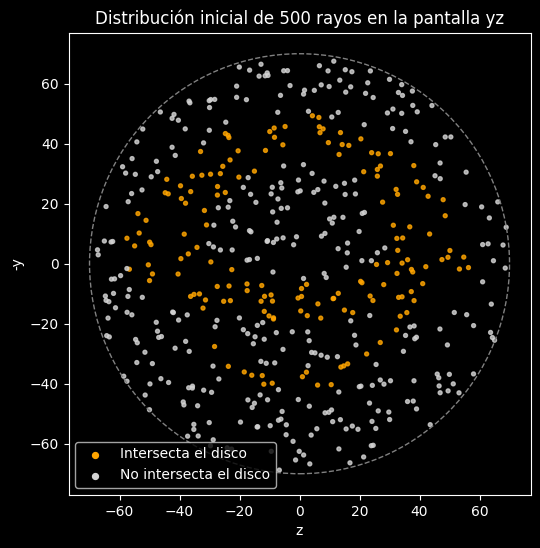

In [32]:
# Verificación con pocos rayos: ¿cuáles pegan al disco?
r0_test, theta0_test, hit_radii_test, captured_test = trace_rays(N, disk_angle_deg=20)
hit_mask = hit_radii_test > 0

print(f"{hit_mask.sum()} de {N} rayos intersectan el disco ({hit_mask.mean():.0%}).")

fig, ax = plt.subplots(figsize=(6, 6))
colors = np.where(hit_mask, "orange", "lightgray")
ax.scatter(r0_test * np.cos(theta0_test), -r0_test * np.sin(theta0_test), s=8, c=colors, alpha=0.8)
ax.add_patch(plt.Circle((0, 0), R, fill=False, ls="--", color="gray"))
ax.scatter([], [], s=18, color="orange", label="Intersecta el disco")
ax.scatter([], [], s=18, color="lightgray", label="No intersecta el disco")
ax.set_xlabel("z")
ax.set_ylabel("-y")
ax.set_aspect("equal")
ax.set_title(f"Distribución inicial de {N} rayos en la pantalla yz")
ax.legend()
plt.show()

In [33]:
def plot_image(screen_radius, launch_angle, hit_radii, title, ax, cmap="hot_r"):
  """Plotea la posición inicial de cada rayo, coloreada según su radio de impacto en el disco."""
  hit_mask = hit_radii > 0
  ax.set_facecolor("black")
  ax.scatter(
    screen_radius[~hit_mask] * np.cos(launch_angle[~hit_mask]),
    -screen_radius[~hit_mask] * np.sin(launch_angle[~hit_mask]),
    color="blue", s=9, alpha=0.15, linewidths=0,
    label="pasan de largo o son capturados",
  )
  image = ax.scatter(
      screen_radius[hit_mask] * np.cos(launch_angle[hit_mask]),
      -screen_radius[hit_mask] * np.sin(launch_angle[hit_mask]),
      c=hit_radii[hit_mask], cmap=cmap, s=8,
      vmin=R_int, vmax=R_ext, linewidths=0,
      label="golpean el disco",
  )
  ax.set_aspect("equal")
  ax.set_xlim(-R, R)
  ax.set_ylim(-R, R)
  ax.set_xlabel("z")
  ax.set_ylabel("-y")
  ax.set_title(title)
  ax.legend(fontsize=8)
  return image

In [ ]:
Nmax = 10000
inclinations = [20, 45, 70]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

print(f'Resultados para {Nmax} rayos')

print('Esto puede tardar unos 3-4 minutos, ve a tomar un respiro. Gracias por la paciencia :)')

for inclination, ax in zip(inclinations, axes):
    r0_big, theta0_big, hit_radii_big, captured_big = trace_rays(Nmax, inclination)
    impacts = np.sum(hit_radii_big > 0)
    image = plot_image(r0_big, theta0_big, hit_radii_big, f"Disco a {inclination}° ({Nmax} rayos)", ax)

    print(
        f"inclinación={inclination}°: "
        f"impactos={impacts}, capturados={captured_big.sum()} ({captured_big.mean():.1%})"
    )
fig.colorbar(image, ax=axes, label="Radio de impacto", shrink=0.85)
plt.show()

Resultados para 10000 rayos
Esto puede tardar unos 3-4 minutos, ve a tomar un respiro. Gracias por la paciencia :)
inclinación=20°: impactos=3019, capturados=2662 (26.6%)


In [ ]:
inclination_zero = 0

fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

r0_small, theta0_small, hit_radii_small, captured_small = trace_rays(Nmax, inclination_zero)
impacts = np.sum(hit_radii_small > 0)
image = plot_image(r0_small, theta0_small, hit_radii_small, f"Disco a {inclination_zero}° ({Nmax} rayos)", ax)

print(
    f"N={Nmax}, inclinación={inclination_zero}°: "
    f"impactos={impacts}, capturados={captured_small.sum()} ({captured_small.mean():.1%})"
)
fig.colorbar(image, ax=ax, label="Radio de impacto", shrink=0.85)
plt.show()

## Análisis e Interpretaciones

Aunque el disco es un anillo plano, no se ve en la pantalla como una elipse, pues es deformado. Se ven dos componentes, una imagen directa y una secundaria. La directa es la cara del disco que ve al observador (que a medida que el ángulo de inclinación crece, se abre en elipse). La imagen secundaria es el arco que aparece arriba, con su contraparte abajo, y corresponde a la cara posterior del disco, su luz rodea el agujero negro antes de llegar al observador ¡Sin el lente gravitacional, esto estaría oculto detrás de la sombra!, es asombroso porque presenciamos cómo la gravidad prácticamente "levanta" esta luz y la hace visible.

La zona interior oscura (la sombra) es circular en las tres inclinaciones, esto porque depende de la geometría del espacio-tiempo, no de la orientación del disco. Además, es importante aclarar que esta zona realmente no representa el horizonte de eventos (el r=A que se tomó); sí muestra la consecuencia de que rayos hayan sido capturados, pero su tamaño angular no es la proporción directa del horizonte, en realidad es mayor porque incluye también todos los fotones que rozan la esfera de fotones y se pierden en órbitas inestables antes de poder escapar.

El borde interno brillante permite identificar claramente los rayos que cruzan el disco en su parte más interna y caliente.

Este modelo no aplica corrimiento Doppler por rotación del disco, por eso es tan simétrico el resultado. En observaciones reales, un lado es mucho más brillante que el otro por el beaming relativista.

**Declaración Ética del uso de IA**

De acuerdo con las recomendaciones de Artificial intelligence-assisted academic
writing: recommendations for ethical use [Cheng et al., 2025], informo que apliqué IA generativa en el proceso de elaboración de este código en: Crear funciones generalizadas a partir de procesos que ya habían sido aplicados en casos específicos, aplicar prácticas de clean-code, aconsejarme en el método de integración y cómo aplicar el cKDTree, estudiar redundancias del código y eliminarlas.

Todo análisis y lógica del desarrollo son producto de inteligencia humana.